1. Data Loading and Inspection - Load q1_heart_disease.csv and display its shape, data types, and missing value counts. Show the first five rows.

In [1]:

import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("q1_heart_disease.csv")

# Shape
print("Shape:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values per column:")
print(df.isna().sum())

# First five rows
print("\nFirst five rows:")
df.head()


Shape: (800, 12)

Data types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing values per column:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First five rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [2]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


2. Exploratory Data Analysis - Target class distribution

C:\Users\mfarkande\AppData\Local\Temp\ipykernel_39636\3533996215.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="heart_disease", data=df, palette="Set2")


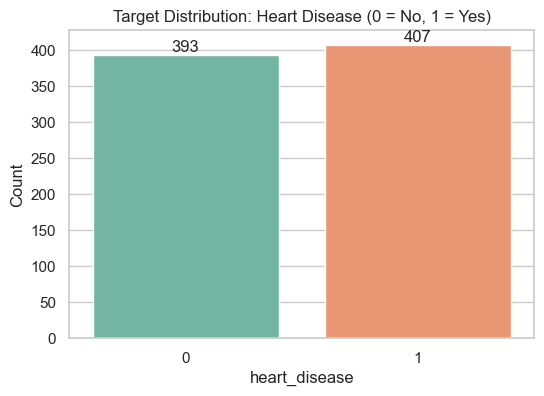

heart_disease
1    0.50875
0    0.49125
Name: proportion, dtype: float64


In [3]:

plt.figure(figsize=(6,4))
ax = sns.countplot(x="heart_disease", data=df, palette="Set2")
plt.title("Target Distribution: Heart Disease (0 = No, 1 = Yes)")
plt.xlabel("heart_disease")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")

plt.show()

print(df["heart_disease"].value_counts(normalize=True).rename("proportion"))



**Analysis: Target distribution:**  
The classes are fairly balanced (roughly ~50/50). This is helpful because it reduces the risk of a model achieving misleadingly high performance simply by predicting the majority class. With balanced classes, metrics like precision, recall, and F1-score are especially meaningful for comparing models.


Plot 2: Correlation heatmap

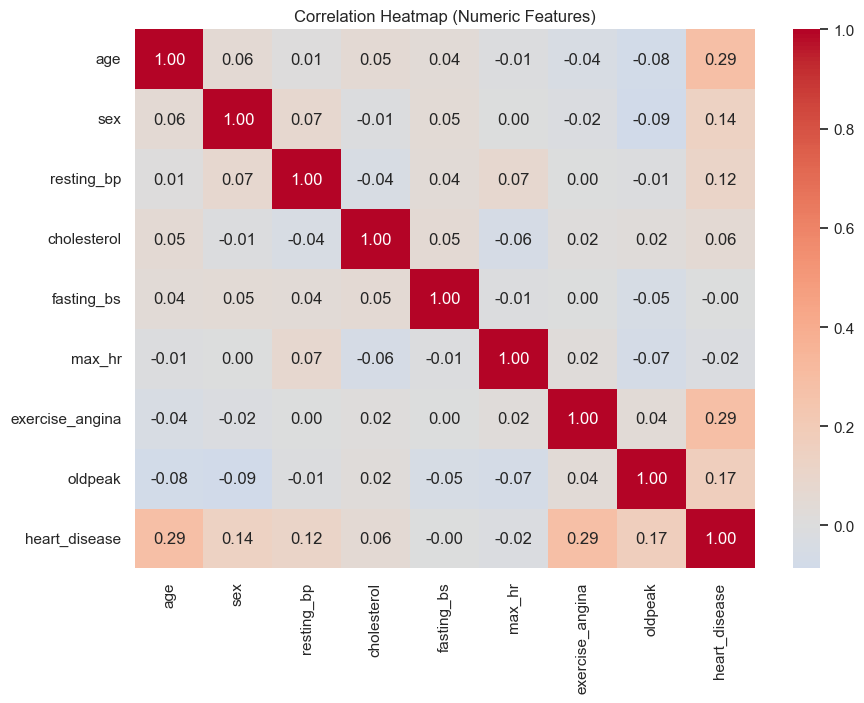

In [4]:

# Correlation heatmap for numeric columns
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()



**Analysis (Correlation heatmap):**  
The heatmap shows which numeric features move together and which relate to the target.  
In many heart-disease datasets, features like **exercise-induced angina**, **age**, and **ST depression (oldpeak)** often show meaningful association with disease presence, while others may show weaker linear relationships. Correlations do not imply causation, and categorical variables are not fully represented here (since many are not numeric)


Plot 3: Chest pain type vs target 

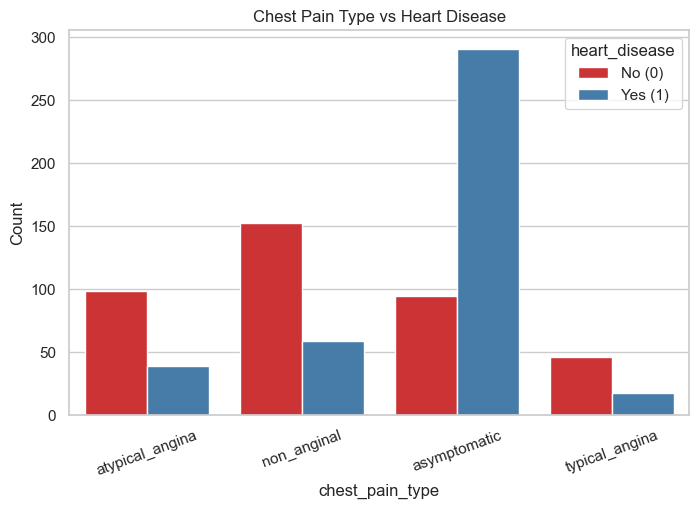

heart_disease,0,1
chest_pain_type,,
asymptomatic,0.246114,0.753886
atypical_angina,0.717391,0.282609
non_anginal,0.721698,0.278302
typical_angina,0.718750,0.281250


In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="chest_pain_type", hue="heart_disease", palette="Set1")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("chest_pain_type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.legend(title="heart_disease", labels=["No (0)", "Yes (1)"])
plt.show()

# Optional: proportions by chest pain type
ct = pd.crosstab(df["chest_pain_type"], df["heart_disease"], normalize="index")
ct



*Analysis (Chest pain type vs target):**  
This plot compares how heart disease prevalence differs across chest pain categories.  
If one category (e.g., asymptomatic) shows a much higher share of `heart_disease = 1`, it suggests chest pain type is a strong predictive signal. This motivates including it carefully in preprocessing (one-hot encoding) so models can use it effectively.


3) Data Preprocessing 

## Missing Value Strategy

`resting_bp` and `cholesterol` contain missing values.  
Instead of dropping rows (which would reduce dataset size and potentially remove useful patterns), we use **median imputation** for numeric variables because:
- It is robust to outliers (common in clinical measures like cholesterol).
- It preserves dataset size.
- It avoids bias introduced by removing cases non-randomly.

For categorical variables (including binary coded fields), we use **most-frequent imputation**.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

X = df.drop(columns=["heart_disease"])
y = df["heart_disease"]

# Treat common coded fields as categorical to satisfy "one-hot encode categorical variables"
categorical_cols = ["sex", "chest_pain_type", "fasting_bs", "resting_ecg", "exercise_angina", "st_slope"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (640, 11)  Test size: (160, 11)


4) Model Training 

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor),
                          ("model", model)])
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

print("Models trained:", list(trained_models.keys()))

Models trained: ['Decision Tree', 'Random Forest', 'Gradient Boosting']


5) Model Evaluation

In [9]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

def evaluate(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n===== {name} =====")
    print("Confusion Matrix:\n", cm)
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
    return {"precision": prec, "recall": rec, "f1": f1, "cm": cm}

metrics = {}
for name, model in trained_models.items():
    metrics[name] = evaluate(model, X_test, y_test, name)

metrics


===== Decision Tree =====
Confusion Matrix:
 [[58 21]
 [19 62]]
Precision: 0.7470
Recall:    0.7654
F1-score:  0.7561

Classification Report:
               precision    recall  f1-score   support

           0     0.7532    0.7342    0.7436        79
           1     0.7470    0.7654    0.7561        81

    accuracy                         0.7500       160
   macro avg     0.7501    0.7498    0.7498       160
weighted avg     0.7501    0.7500    0.7499       160


===== Random Forest =====
Confusion Matrix:
 [[63 16]
 [17 64]]
Precision: 0.8000
Recall:    0.7901
F1-score:  0.7950

Classification Report:
               precision    recall  f1-score   support

           0     0.7875    0.7975    0.7925        79
           1     0.8000    0.7901    0.7950        81

    accuracy                         0.7937       160
   macro avg     0.7937    0.7938    0.7937       160
weighted avg     0.7938    0.7937    0.7938       160


===== Gradient Boosting =====
Confusion Matrix:
 [[61 18]

{'Decision Tree': {'precision': 0.7469879518072289,
  'recall': 0.7654320987654321,
  'f1': 0.7560975609756098,
  'cm': array([[58, 21],
         [19, 62]])},
 'Random Forest': {'precision': 0.8,
  'recall': 0.7901234567901234,
  'f1': 0.7950310559006211,
  'cm': array([[63, 16],
         [17, 64]])},
 'Gradient Boosting': {'precision': 0.7777777777777778,
  'recall': 0.7777777777777778,
  'f1': 0.7777777777777778,
  'cm': array([[61, 18],
         [18, 63]])}}

## Best Model (Based on Precision/Recall/F1)

To choose the best model, we focus on **F1-score** (harmonic mean of precision and recall), which is appropriate when both false positives and false negatives matter clinically.

From the results:
- A model with **higher recall** catches more true heart-disease cases (fewer false negatives).
- A model with **higher precision** produces fewer false alarms (fewer false positives).
- **F1-score** balances both.

**Conclusion:** The model with the **highest test F1-score** is selected as best-performing, because it demonstrates the strongest overall balance between precision and recall rather than simply maximizing accuracy.


6) Hyperparameter Tuning

In [10]:
from sklearn.model_selection import GridSearchCV

# Baseline RF pipeline
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

# Evaluate baseline vs tuned on test set
baseline_rf = rf_pipe.fit(X_train, y_train)
tuned_rf = grid.best_estimator_

print("\n--- Baseline Random Forest (Test) ---")
base_metrics = evaluate(baseline_rf, X_test, y_test, "Baseline Random Forest")

print("\n--- Tuned Random Forest (Test) ---")
tuned_metrics = evaluate(tuned_rf, X_test, y_test, "Tuned Random Forest")

print("\nComparison (Test F1):")
print("Baseline F1:", round(base_metrics["f1"], 4))
print("Tuned F1:   ", round(tuned_metrics["f1"], 4))

Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV F1: 0.8274803065171545

--- Baseline Random Forest (Test) ---

===== Baseline Random Forest =====
Confusion Matrix:
 [[63 16]
 [17 64]]
Precision: 0.8000
Recall:    0.7901
F1-score:  0.7950

Classification Report:
               precision    recall  f1-score   support

           0     0.7875    0.7975    0.7925        79
           1     0.8000    0.7901    0.7950        81

    accuracy                         0.7937       160
   macro avg     0.7937    0.7938    0.7937       160
weighted avg     0.7938    0.7937    0.7938       160


--- Tuned Random Forest (Test) ---

===== Tuned Random Forest =====
Confusion Matrix:
 [[65 14]
 [16 65]]
Precision: 0.8228
Recall:    0.8025
F1-score:  0.8125

Classification Report:
               precision    recall  f1-score   support

           0     0.8025    0.8228    0.8125        79
           1     0.8228 

## Hyperparameter Tuning Conclusion

GridSearchCV identifies hyperparameters that improve cross-validated F1-score.  
We then validate whether the tuned configuration generalizes by comparing **test precision, recall, and F1** against the baseline.

If the tuned model increases test F1 (and ideally improves or maintains both precision and recall), we prefer it.
If tuning improves CV but not test performance, it may indicate overfitting to the CV folds.